# Avaliação ML — Árvore de Decisão

**Aluno:** Leonardo Fernandes Costa
**Data:** 02/07/2026  
**Dataset:** Bank Marketing (UCI)  
**Objetivo:** Prever adesão a depósito a prazo usando Árvore de Decisão

## 1. Introdução

[Escreva 2-3 frases: qual é o problema de negócio? Por que prever adesão? Quantas variáveis tem o dataset?]

## 2. Exploração de Dados (EDA)

In [44]:
# biliotecas importadas

In [50]:
# Carregue o arquivo CSV

Shape: (41188, 21)

Primeiras linhas:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [48]:
# Tipos de dados e valores ausentes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  campaign        41176 non-null  int64  
 11  pdays           41176 non-null  int64  
 12  previous        41176 non-null  int64  
 13  poutcome        41176 non-null  object 
 14  emp.var.rate    41176 non-null  float64
 15  cons.price.idx  41176 non-null  float64
 16  cons.conf.idx   41176 non-null  float64
 17  euribor3m       41176 non-null 

In [10]:
# Distribuição do alvo (y)

Distribuição de y:
y
no     36548
yes     4640
Name: count, dtype: int64

Proporção (%):
y
no     88.7
yes    11.3
Name: proportion, dtype: float64

⚠️ Dataset DESBALANCEADO: apenas 11.3% são 'sim'


In [12]:
# Contar valores 'unknown' nas categóricas

Valores 'unknown' por coluna:


default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64

In [14]:
# Verificar duplicatas


Linhas duplicadas: 12
Shape após remover duplicatas: (41176, 21)


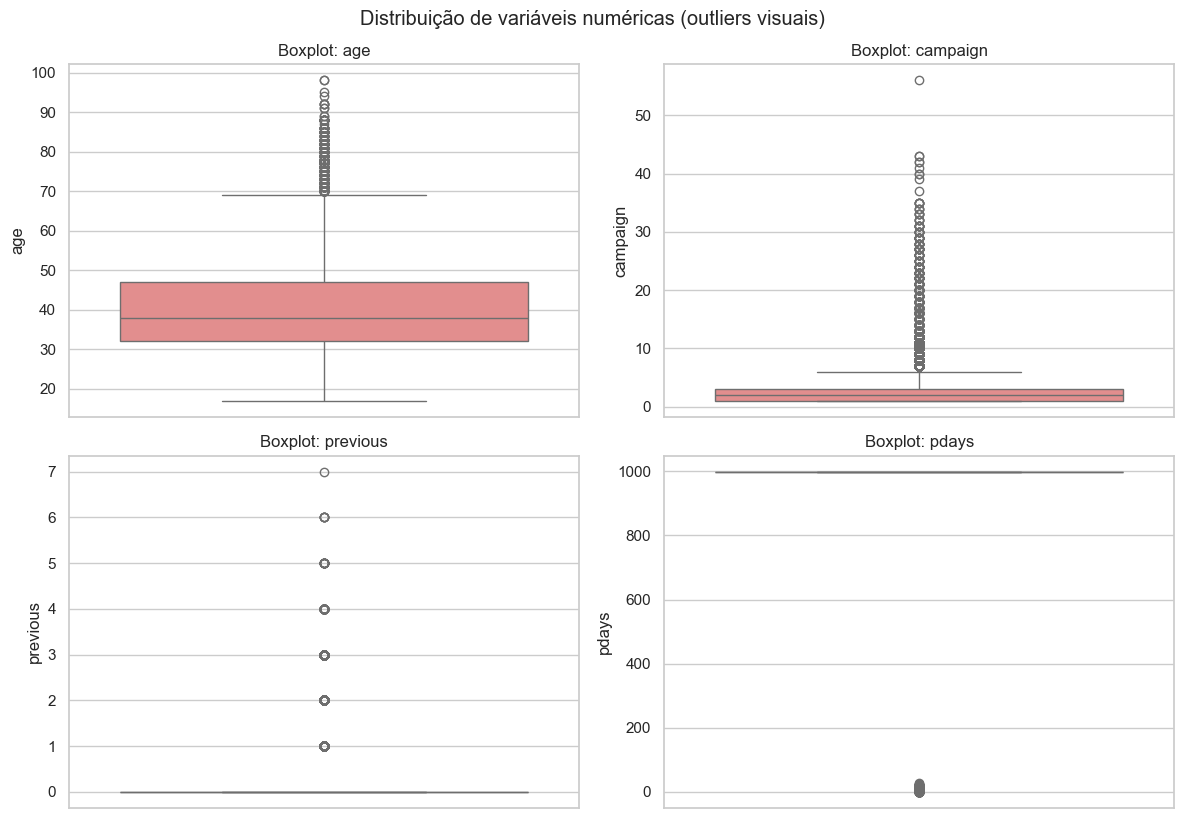


Observações:
Age: min=17, max=98
Campaign: min=1, max=56
Previous: min=0, max=7


In [16]:
# Visualizar distribuição de variáveis numéricas importantes


### Observações da EDA:
[Escreva aqui suas descobertas]
- O dataset está balanceado ou desbalanceado?
- Quais variáveis têm muitos "unknown"?
- Que outliers você encontrou?

## 3. Pré-processamento

In [20]:
from sklearn.model_selection import train_test_split

# Remove a coluna 'duration' — DATA LEAKAGE
# (A duração só é conhecida DEPOIS que a ligação termina, mas queremos prever ANTES)
print("Removendo 'duration' (data leakage)...")


Removendo 'duration' (data leakage)...
X shape: (41176, 19), y shape: (41176,)


In [21]:
# One-hot encoding de variáveis categóricas
cat_features = X.select_dtypes(include="object").columns.tolist()
print(f"Colunas categóricas a codificar: {cat_features}")

X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)
print(f"\nX_encoded shape (após encoding): {X_encoded.shape}")
print(f"Nº de features: {X_encoded.shape[1]}")

Colunas categóricas a codificar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

X_encoded shape (após encoding): (41176, 52)
Nº de features: 52


In [22]:
# Split treino/teste (75/25, com stratificação para manter proporção)


Treino: (30882, 52), Teste: (10294, 52)

y_train distribuição: {0: 27403, 1: 3479}
y_test distribuição: {0: 9134, 1: 1160}


## 4. Modelo: Árvore de Decisão

In [27]:
#importar modelos

In [29]:
# Treinar árvore de decisão


✓ Árvore treinada com sucesso!


In [54]:
# Calcular 3 métricas obrigatórias

print("=== MÉTRICAS DA ÁRVORE DE DECISÃO ===")
print(f"Acurácia:  {acuracia:.3f}")
print(f"Precisão:  {precisao:.3f}")
print(f"Recall:    {recall:.3f}")



=== MÉTRICAS DA ÁRVORE DE DECISÃO ===
Acurácia:  0.847
Precisão:  0.389
Recall:    0.626


<Figure size 800x600 with 0 Axes>

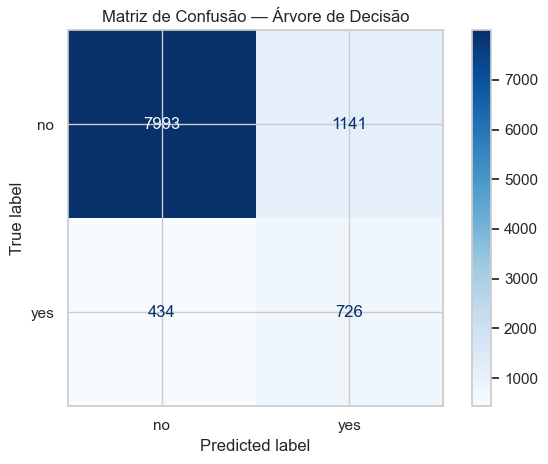


Interpretação da matriz:
Verdadeiros Negativos (TN): 7993 — clientes que NÃO comprariam (predição correta)
Falsos Positivos (FP): 1141 — clientes que NÃO comprariam (predição errada — alerta falso)
Falsos Negativos (FN): 434 — clientes que COMPRARIAM (perdemos venda!)
Verdadeiros Positivos (TP): 726 — clientes que COMPRARIAM (predição correta)


In [33]:
# Matriz de confusão


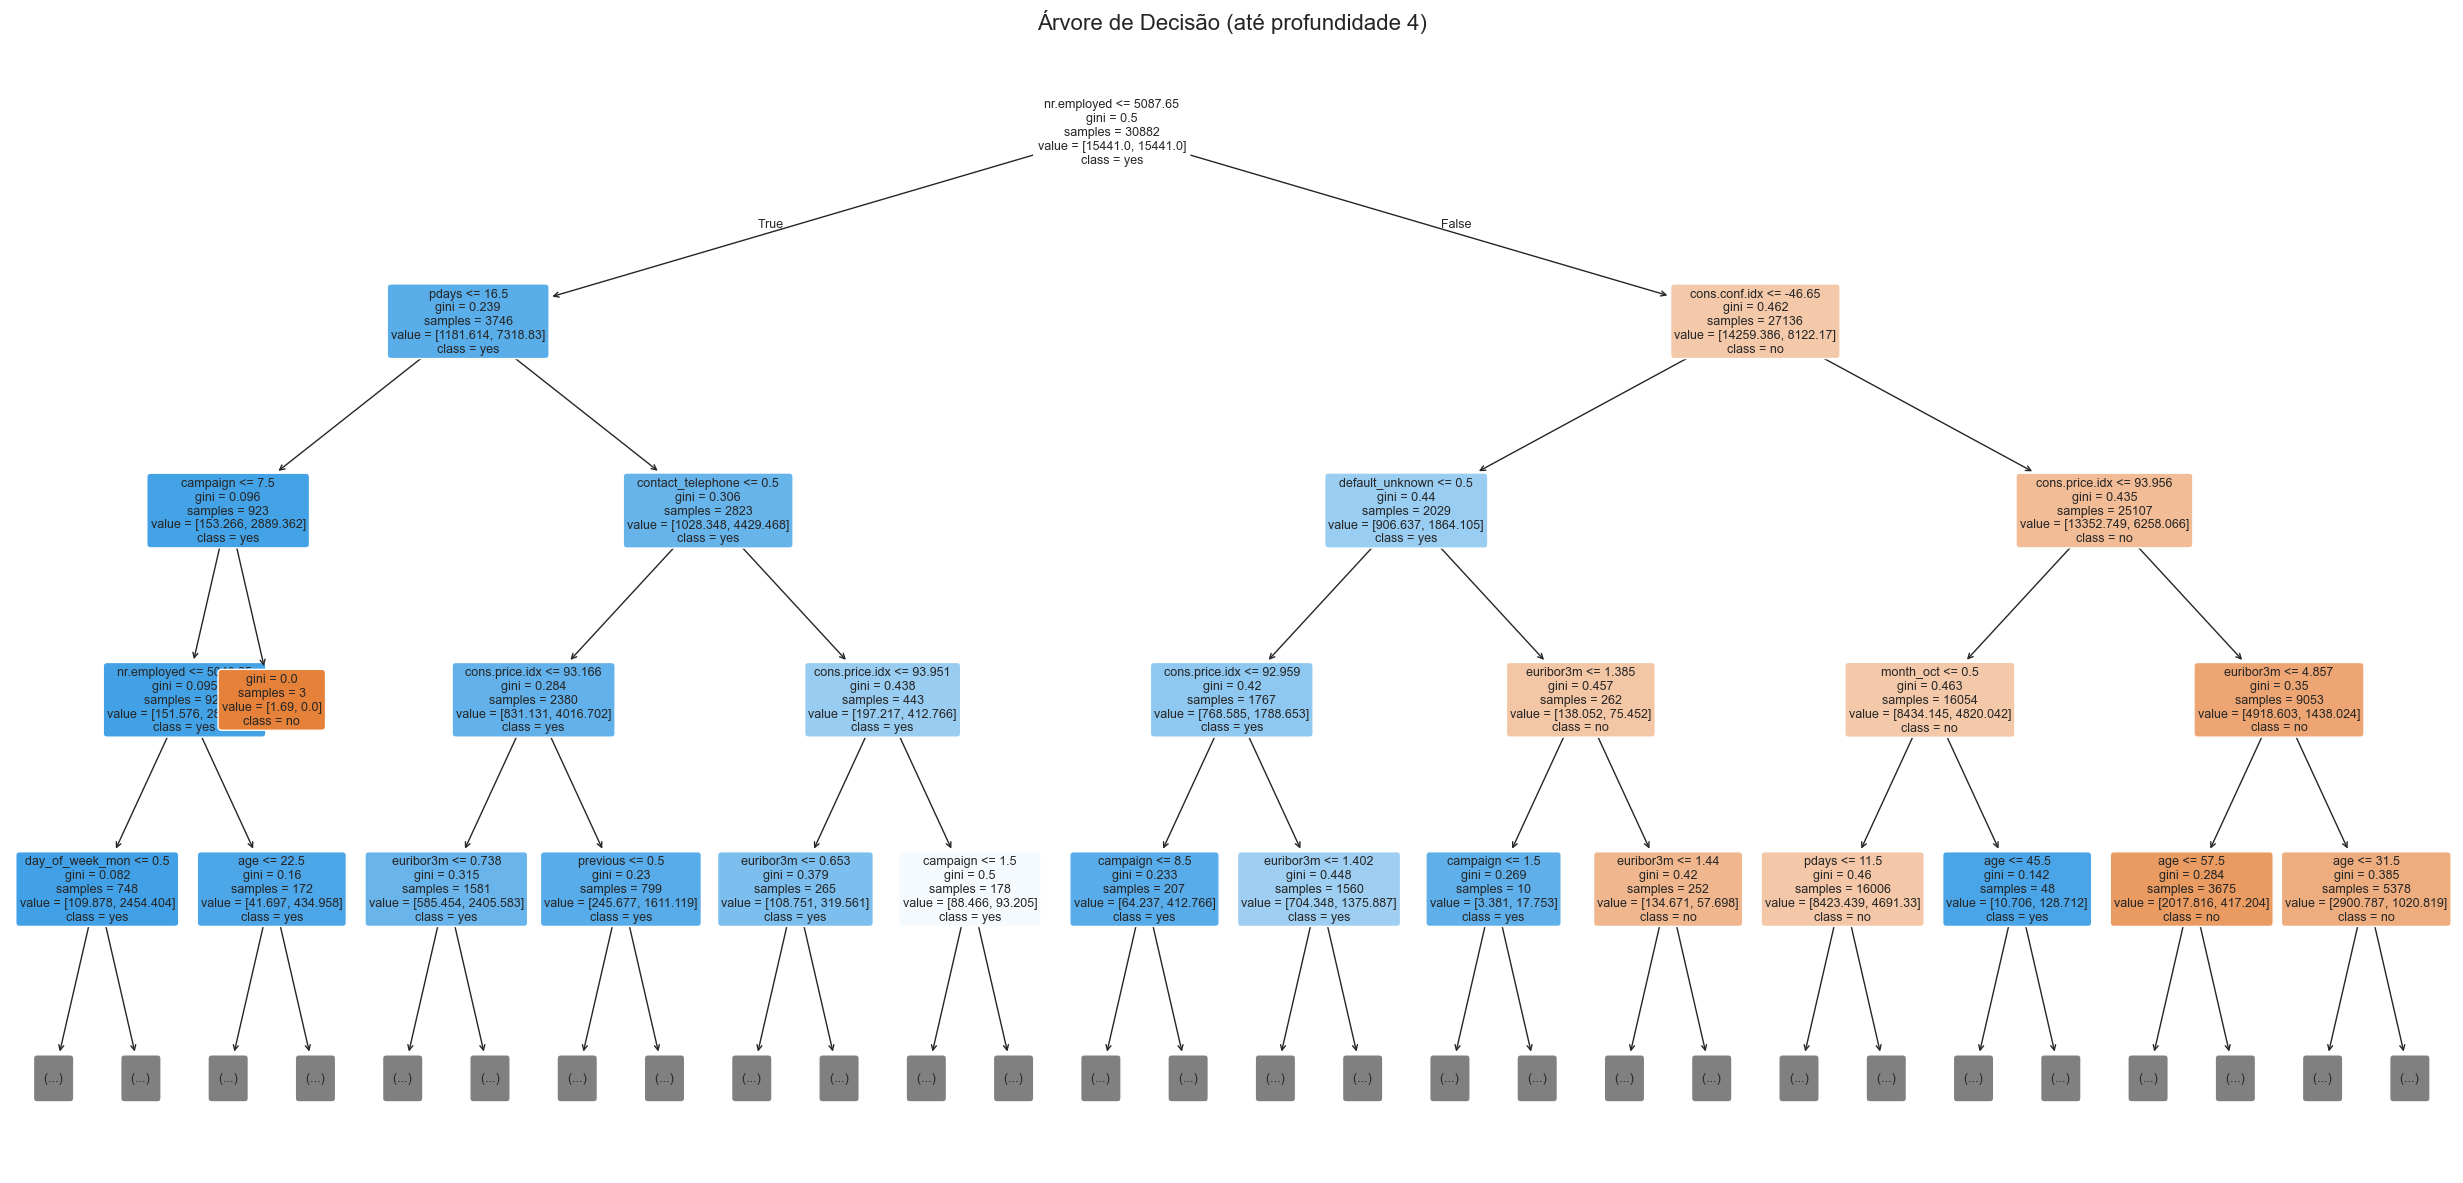


Profundidade total da árvore: 5
Nº de nós: 57


In [35]:
# Visualizar a árvore (primeiros níveis)
plt.figure(figsize=(25, 12))
plot_tree(
    arvore,
    feature_names=X_encoded.columns,
    class_names=["no", "yes"],
    filled=True,
    max_depth=4,  # mostrar até 4 níveis para não ficar muito confuso
    fontsize=9,
    rounded=True
)
plt.title("Árvore de Decisão (até profundidade 4)", fontsize=16)
plt.tight_layout()
plt.show()

print(f"\nProfundidade total da árvore: {arvore.get_depth()}")
print(f"Nº de nós: {arvore.tree_.node_count}")

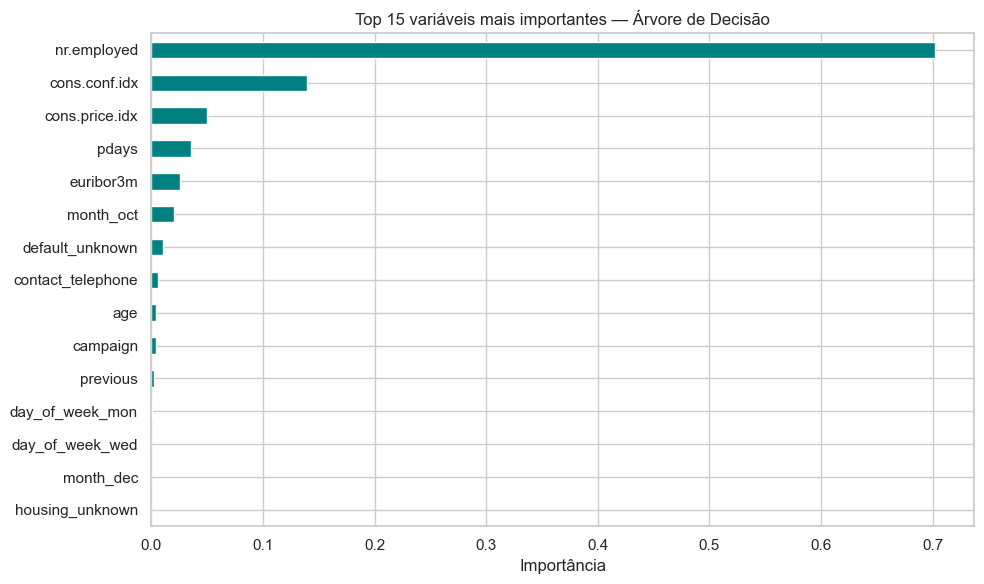


Top 10 variáveis mais importantes:
nr.employed          0.701932
cons.conf.idx        0.139382
cons.price.idx       0.049950
pdays                0.035517
euribor3m            0.025751
month_oct            0.020249
default_unknown      0.010831
contact_telephone    0.005736
age                  0.004087
campaign             0.003965
dtype: float64


In [36]:
# Importância das variáveis
importancias = pd.Series(arvore.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind="barh", color="teal")
plt.title("Top 15 variáveis mais importantes — Árvore de Decisão", fontsize=12)
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 variáveis mais importantes:")
print(importancias.head(10))

## 5. Interpretação da Árvore

[Responda com base na visualização acima]

### Primeira regra (root node):
[Qual é a variável usada no primeiro split? Qual é o valor de corte (threshold)? Você acha que faz sentido para este problema de negócio?]

### Variáveis mais importantes:
[Cite as 3 variáveis com maior importância. Por que você acha que a árvore as considerou importantes? Fazem sentido para prever adesão a depósito?]

## 6. Análise de sensibilidade

[Escreva suas reflexões]

### Limitações identificadas:
1. **Data leakage em `duration`:** qual é o problema? Como afetaria um modelo em produção?
2. **Dataset desbalanceado:** por que isso pode ser um problema? Como o `class_weight="balanced"` ajuda?
3. **Overfitting/Underfitting:** a árvore ficou muito profunda? Muito rasa? Por quê?

### Aplicação de negócio:
- Se você fosse o gerente de marketing, como usaria este modelo para melhorar as campanhas?
- Como priorizaria os contatos telefônicos?
- Quais seria os próximos passos?

### Se tivesse mais tempo:
- Que melhorias faria no modelo?
- Testaria outros parâmetros? Quais?

## 7. Limitações e Conclusões

[Escreva suas reflexões]

### Limitações identificadas:
1. **Data leakage em `duration`:** qual é o problema? Como afetaria um modelo em produção?
2. **Dataset desbalanceado:** por que isso pode ser um problema? Como o `class_weight="balanced"` ajuda?
3. **Overfitting/Underfitting:** a árvore ficou muito profunda? Muito rasa? Por quê?

### Aplicação de negócio:
- Se você fosse o gerente de marketing, como usaria este modelo para melhorar as campanhas?
- Como priorizaria os contatos telefônicos?
- Quais seria os próximos passos?

### Se tivesse mais tempo:
- Que melhorias faria no modelo?
- Testaria outros parâmetros? Quais?